https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance


Dataset "Student Habits vs Academic Performance" trên Kaggle (do tác giả Jayanta Nath chia sẻ) là một bộ dữ liệu rất phổ biến, thường được sử dụng cho các bài toán Khoa học dữ liệu (Data Science) và Học máy (Machine Learning) nhằm phân tích xem thói quen sinh hoạt, học tập và lối sống hằng ngày ảnh hưởng như thế nào đến kết quả thi cử của học sinh/sinh viên.   

1. Tổng quan cấu trúc DatasetSố lượng mẫu (Rows): Khoảng 1.000 dòng dữ liệu (tương ứng với thông tin của 1.000 học sinh/sinh viên).   Số lượng thuộc tính (Columns): 16 cột (bao gồm 1 mã định danh, 14 biến đầu vào/features và 1 biến mục tiêu/target).   

2. Chi tiết các cột dữ liệu (Columns)Bộ dữ liệu pha trộn cả dữ liệu dạng số (numerical) và dạng phân loại (categorical):   student_id: Mã định danh của học sinh (ví dụ: S1000, S1001...).   age: Độ tuổi của học sinh.   gender: Giới tính (Nam/Nữ...).   study_hours_per_day: Số giờ tự học mỗi ngày.   social_media_hours: Số giờ lướt mạng xã hội mỗi ngày.   net_flix_hours (hoặc thời gian giải trí tương tự): Số giờ xem phim, giải trí trực tuyến mỗi ngày.   part_time_job: Học sinh có đi làm thêm hay không (Yes/No).   attendance_percentage: Tỷ lệ tham gia lớp học trên trường (%).   sleep_hours: Số giờ ngủ trung bình mỗi đêm.   diet_quality: Chất lượng chế độ ăn uống (Ví dụ: Poor - Kém, Fair - Trung bình, Good - Tốt).   exercise_frequency: Tần suất tập thể dục (số lần mỗi tuần).   parental_education_level: Trình độ học vấn của bố mẹ (Ví dụ: High School, Bachelor, Master...).   internet_quality: Chất lượng đường truyền internet tại nhà (Poor, Average, Good).   mental_health_rating: Đánh giá về sức khỏe tinh thần (thang điểm từ 1 đến 10).   extracurricular_participation: Có tham gia hoạt động ngoại khóa không (Yes/No).   exam_score (Biến mục tiêu - Target): Điểm số bài kiểm tra hoặc kết quả học tập (dạng số liên tục).   

3. Mục đích và bài toán có thể giải quyết với Dataset nàyNhờ tính trực quan và đa dạng của các biến, dataset này thường được dùng để thực hiện các project như:Bài toán Hồi quy (Regression): Xây dựng các mô hình Machine Learning (như Linear Regression, Random Forest Regressor, XGBoost...) để dự đoán chính xác điểm số (exam_score) của một học sinh dựa trên các thói quen sống và học tập của họ.   Bài toán Phân loại (Classification): Chuyển biến exam_score thành dạng phân loại (Ví dụ: Đạt/Trượt, hoặc chia thành các mức Giỏi/Khá/Trung bình) để dự đoán xem học sinh đó có nguy cơ học kém hay không.Phân tích mức độ quan trọng của đặc trưng (Feature Importance): Tìm hiểu xem yếu tố nào tác động lớn nhất đến điểm số? (Ví dụ: Số giờ học chiếm ưu thế hơn hay thời gian ngủ và mạng xã hội mới là cốt lõi?). Việc này thường được hỗ trợ bởi các thư viện như SHAP hoặc phân tích độ quan trọng của Random Forest.   

In [2]:
import pandas as pd

df = pd.read_csv("student_habits_performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df.shape

(1000, 16)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set(style="whitegrid")

In [8]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [9]:
df.isna().sum().sum()

np.int64(91)

In [10]:
df.dropna(inplace=True)

In [12]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [13]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [18]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1000,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [20]:
df.describe(include="object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [19]:
categorical_cols = ["gender", "part_time_job", "diet_quality", "parental_education_level", "internet_quality",
"extracurricular_participation"]

In [23]:
for col in categorical_cols:
    print(f"Value counts for {col}: \n {df[col].value_counts()}")

Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


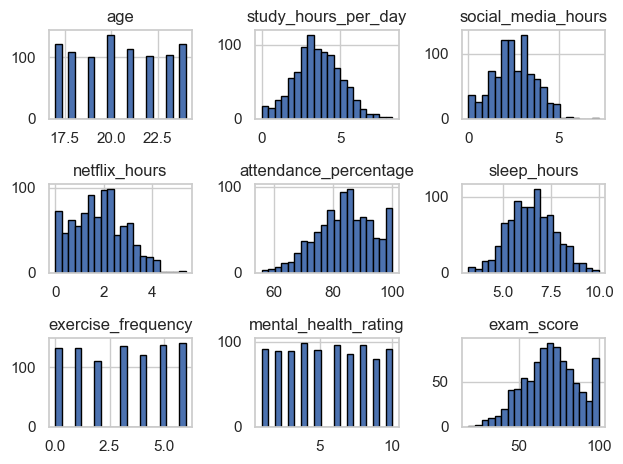

In [24]:
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

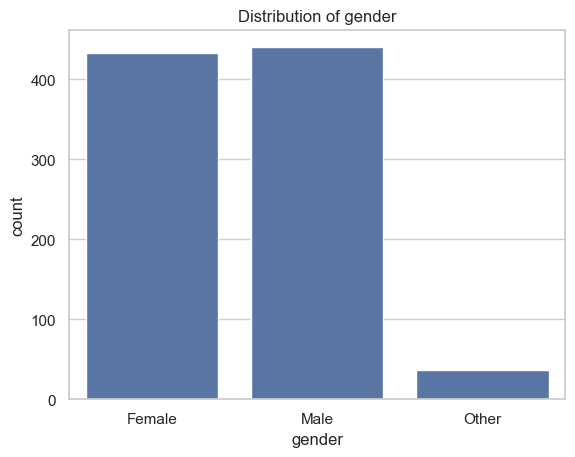

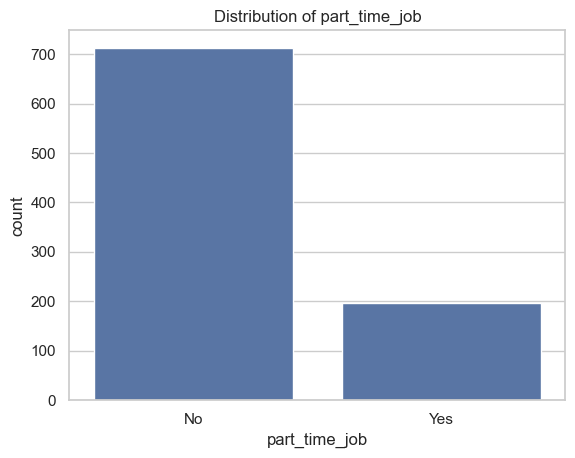

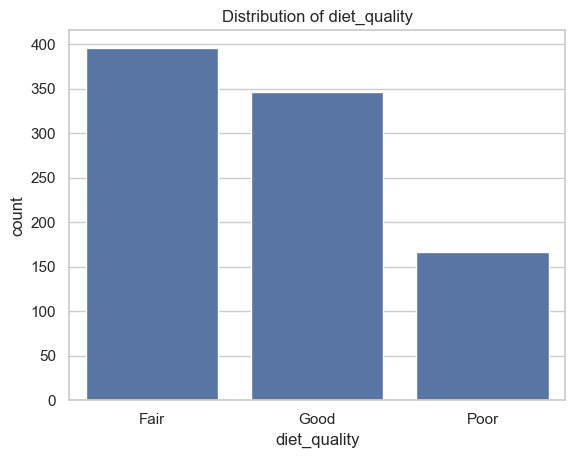

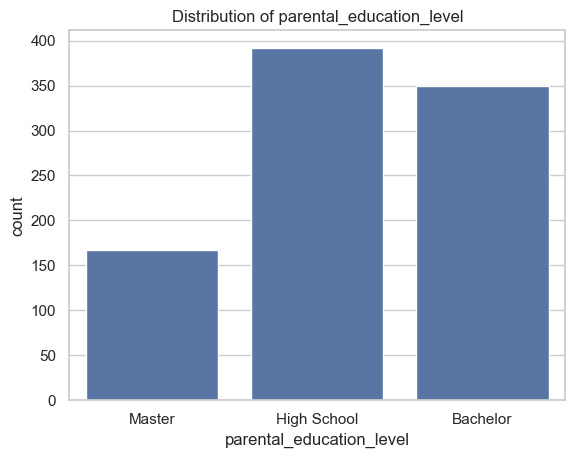

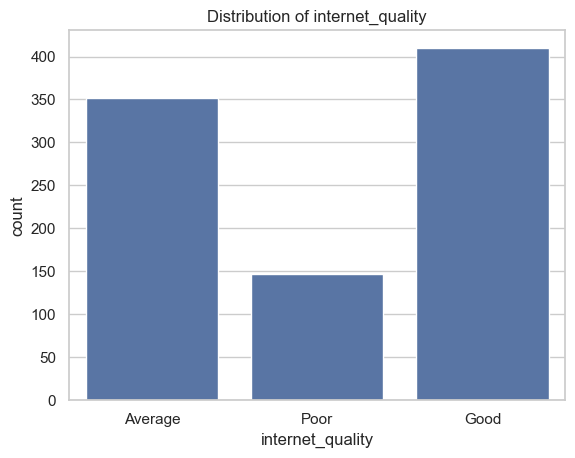

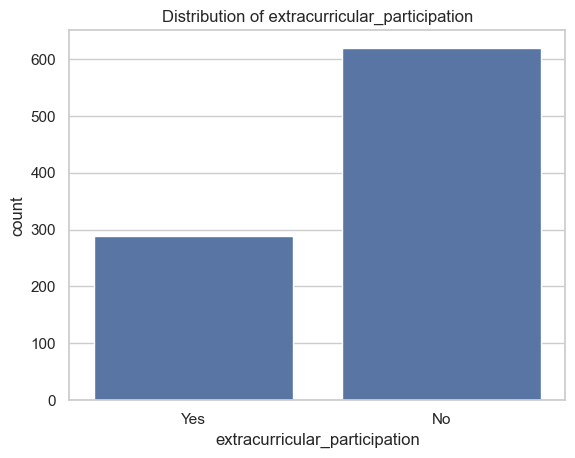

In [25]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

In [26]:
df.corr(numeric_only=True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.007150,-0.023854,0.005841,-0.030203,0.040498,-0.005718,-0.052137,-0.012833
study_hours_per_day,0.007150,1.000000,0.007364,-0.014493,0.028967,-0.026241,-0.024708,-0.015896,0.822950
social_media_hours,-0.023854,0.007364,1.000000,0.011865,0.049356,0.026861,-0.023975,-0.000417,-0.171672
netflix_hours,0.005841,-0.014493,0.011865,1.000000,-0.015008,-0.017006,-0.004155,-0.016612,-0.166578
attendance_percentage,-0.030203,0.028967,0.049356,-0.015008,1.000000,0.001972,-0.010563,-0.017096,0.096005
sleep_hours,0.040498,-0.026241,0.026861,-0.017006,0.001972,1.000000,0.030013,-0.010653,0.122294
exercise_frequency,-0.005718,-0.024708,-0.023975,-0.004155,-0.010563,0.030013,1.000000,-0.001500,0.161397
mental_health_rating,-0.052137,-0.015896,-0.000417,-0.016612,-0.017096,-0.010653,-0.001500,1.000000,0.317945
exam_score,-0.012833,0.822950,-0.171672,-0.166578,0.096005,0.122294,0.161397,0.317945,1.000000


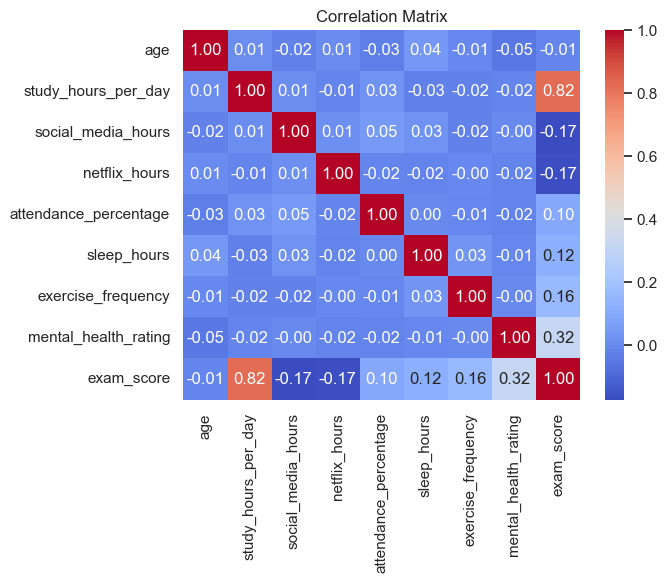

In [27]:
from matplotlib.cm import coolwarm
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=coolwarm, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

biểu đồ nhiệt thể hiện ma trận tương quan (Correlation Matrix) cho các cột dữ liệu dạng số trong một DataFrame của thư viện Pandas. Đây là một bước cực kỳ phổ biến trong Phân tích khám phá dữ liệu (EDA) để xem xét mối quan hệ tuyến tính giữa các biến với nhau.

1: Tương quan thuận hoàn toàn (khi biến này tăng thì biến kia cũng tăng).

-1: Tương quan nghịch hoàn toàn (khi biến này tăng thì biến kia giảm).

0: Không có mối quan hệ tuyến tính.

In [28]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [29]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score']

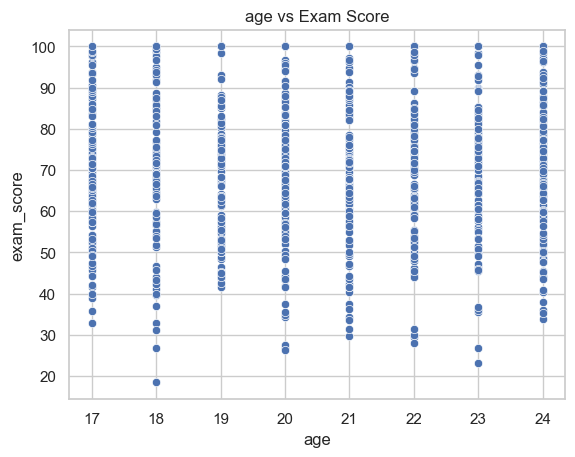

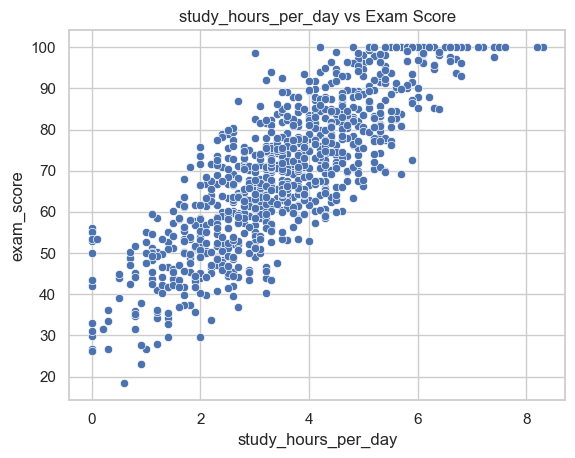

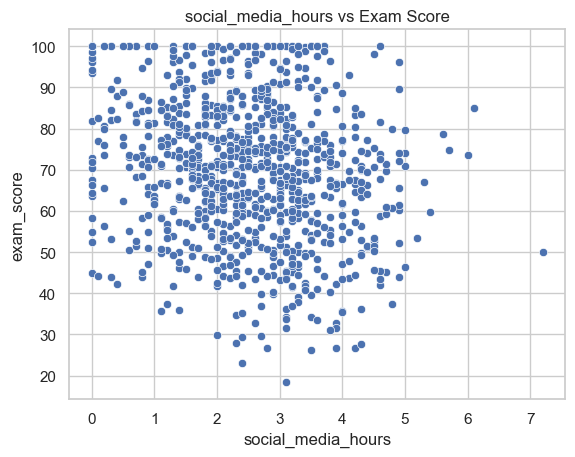

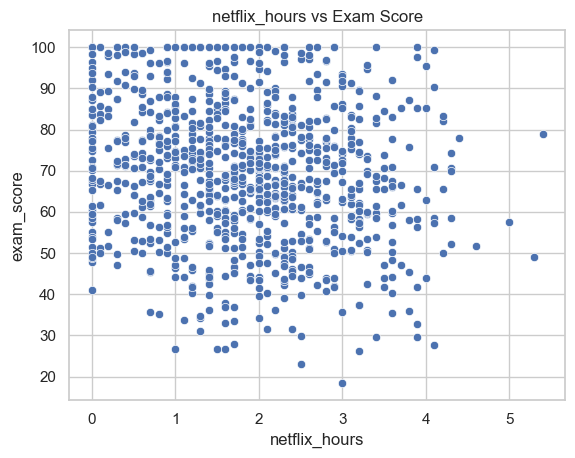

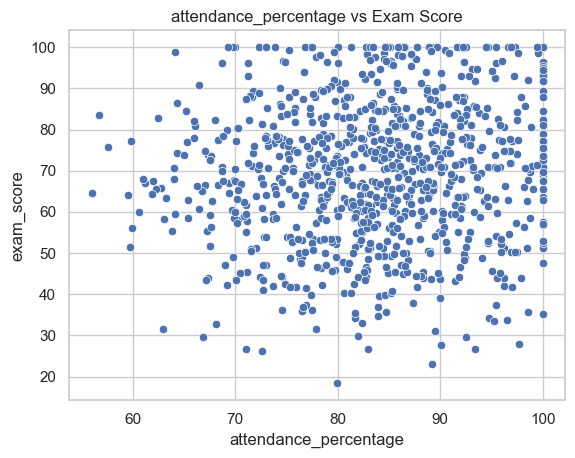

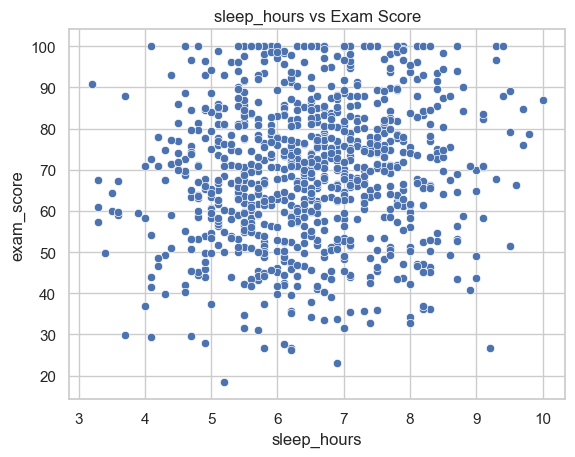

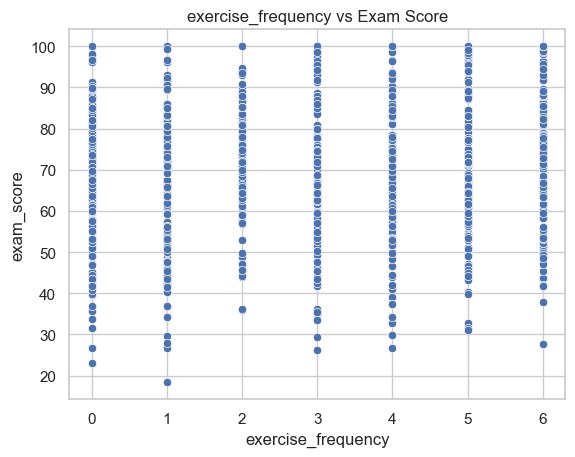

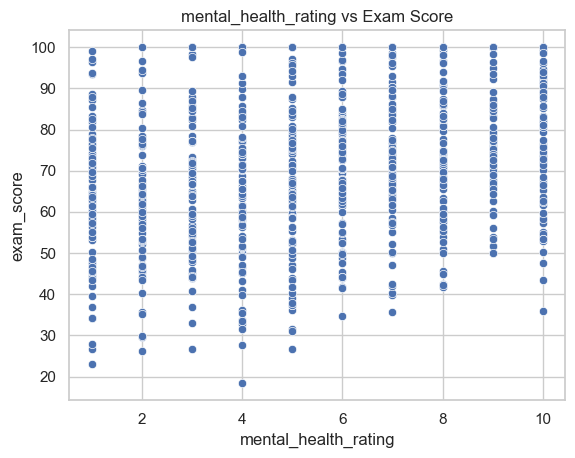

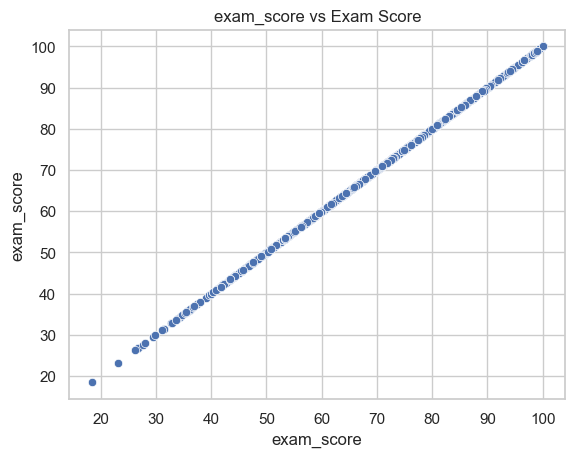

In [31]:
for feature in num_features:
    sns.scatterplot(data=df, x=feature, y="exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

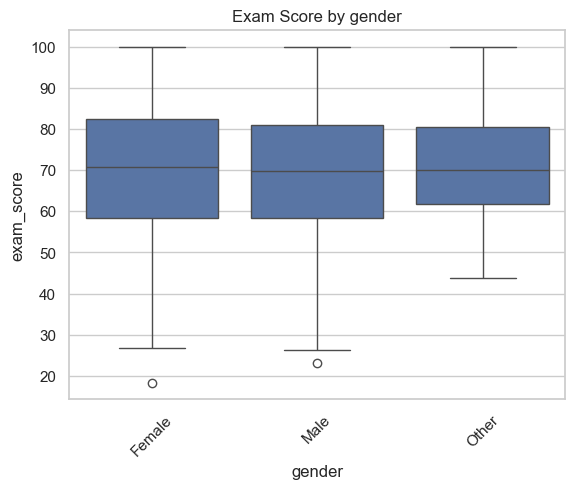

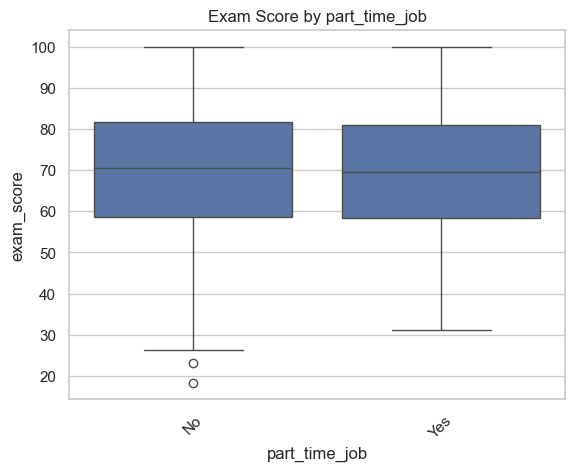

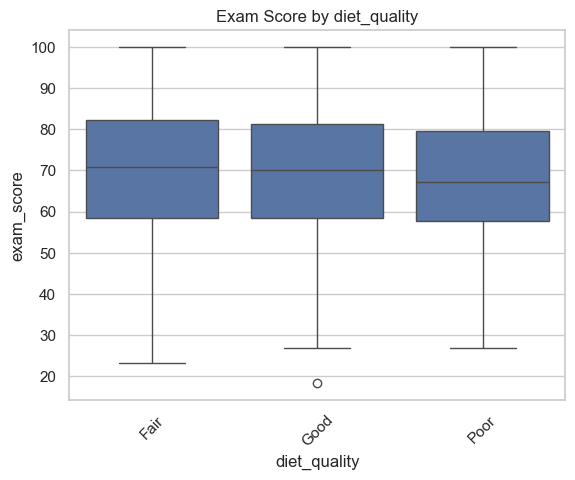

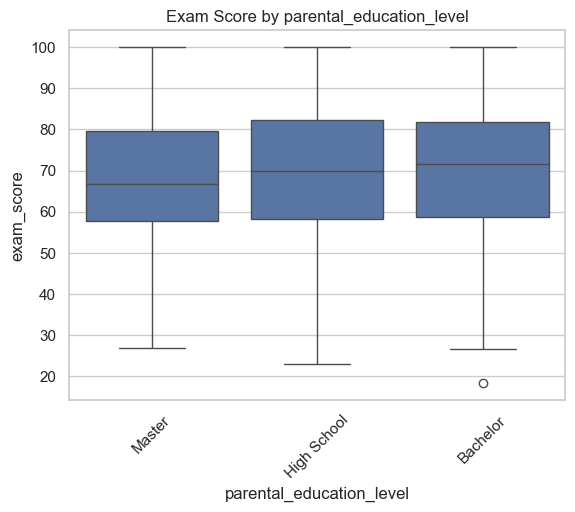

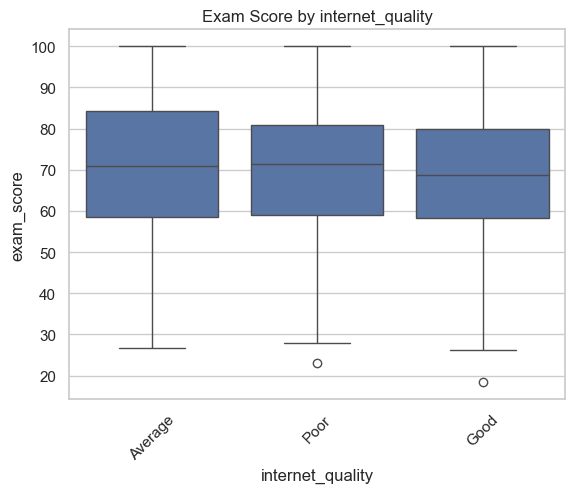

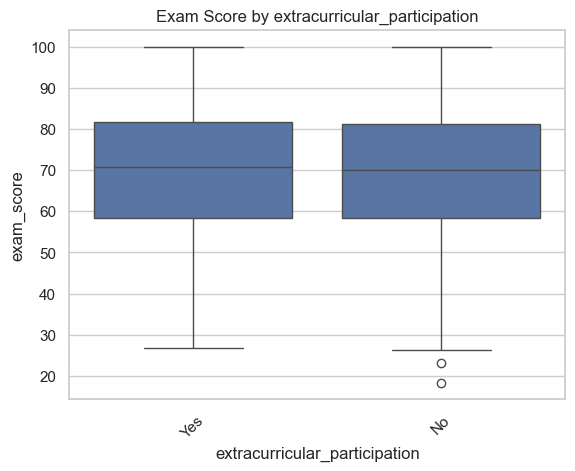

In [32]:
for col in categorical_cols:
    sns.boxplot(data=df, x=col, y ="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

1. Chia tách dữ liệu & Tối ưu hóa mô hình
train_test_split: Dùng để chia tập dữ liệu của bạn thành 2 phần: tập huấn luyện (train - ví dụ 80%) để máy học và tập kiểm thử (test - ví dụ 20%) để đánh giá xem mô hình học có tốt không.

GridSearchCV: Công cụ tự động dò tìm (grid search) kết hợp kiểm định chéo (cross-validation) để tìm ra bộ tham số tốt nhất cho mô hình Machine Learning của bạn (giúp mô hình đạt độ chính xác cao nhất).

2. Tiền xử lý dữ liệu
LabelEncoder: Dùng để chuyển đổi các cột dữ liệu dạng chữ (categorical, dạng phân loại như "Yes"/"No", "Good"/"Poor") thành các con số (0, 1, 2...) để các thuật toán toán học trong Machine Learning có thể hiểu và tính toán được.

3. Các hàm đánh giá độ chính xác (Metrics)
mean_squared_error (MSE): Sai số bình phương trung bình. Dùng để đo lường khoảng cách trung bình từ giá trị dự đoán đến giá trị thực tế (số này càng nhỏ thì mô hình càng chuẩn).

r2_score (R-squared): Hệ số xác định. Đo lường xem mô hình của bạn giải thích được bao nhiêu phần trăm sự biến thiên của dữ liệu (giá trị chuẩn từ 0 đến 1, càng gần 1 mô hình càng xịn).

4. Các thuật toán học máy (Models) dùng cho bài toán Hồi quyLinearRegression: Mô hình Hồi quy tuyến tính cơ bản nhất (dựa trên phương trình đường thẳng $y = ax + b$).Ridge: Mô hình Hồi quy tuyến tính có thêm phần điều chuẩn (Regularization) giúp chống hiện tượng học tủ (overfitting).RandomForestRegressor: Mô hình Rừng ngẫu nhiên, kết hợp hàng loạt cây quyết định lại với nhau để đưa ra dự đoán cực kỳ mạnh mẽ và chính xác.DecisionTreeRegressor: Mô hình Cây quyết định đơn lẻ, hoạt động dựa trên việc đặt các câu hỏi điều kiện (ví dụ: Nếu số giờ học > 3 và ngủ > 6 tiếng thì điểm sẽ khoảng bao nhiêu?).

In [35]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [36]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [37]:
features = ["study_hours_per_day", "attendance_percentage", "mental_health_rating", "sleep_hours", "part_time_job"]

In [38]:
target = "exam_score"

In [40]:
df_model = df[features + [target]].copy()

In [41]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [42]:
le = LabelEncoder()

In [43]:
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [44]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [45]:
X = df_model[features]

In [46]:
y = df_model[target]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [48]:
len(y_test)

182

In [49]:
len(y_train)

727

In [53]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {
            "max_depth": [3,5,10],
            "min_samples_split": [2,5],
        },
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators": [50,100],
            "max_depth": [5,10]
            }
    }
}

1. LinearRegression (Hồi quy tuyến tính)
model: LinearRegression(): Khởi tạo mô hình hồi quy tuyến tính.

params: {}: Để trống vì mô hình tuyến tính chuẩn không có các siêu tham số (hyperparameters) dạng cấu trúc cần tối ưu như cây quyết định.

2. DecisionTree (Cây quyết định)
model: DecisionTreeRegressor(): Mô hình cây quyết định dự đoán giá trị liên tục.

params:

"max_depth": [3, 5, 10]: Giới hạn độ sâu tối đa của cây (thử lần lượt 3, 5 hoặc 10 tầng). Tránh việc cây mọc quá sâu gây ra hiện tượng học tủ (overfitting).

"min_samples_split": [2, 5]: Số lượng mẫu tối thiểu cần thiết để tiếp tục chia nhỏ một nhánh (thử 2 hoặc 5 mẫu).

3. RandomForest (Rừng ngẫu nhiên)
model: RandomForestRegressor(): Mô hình tập hợp nhiều cây quyết định.

params:

"n_estimators": [50, 100]: Số lượng cây quyết định có trong khu rừng (thử tạo 50 cây hoặc 100 cây).

"max_depth": [5, 10]: Độ sâu tối đa cho mỗi cây trong rừng (thử mức 5 hoặc 10).

In [51]:
best_models = []

In [54]:
for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(
        config["model"], 
        config["params"], 
        cv=5,
        scoring="neg_mean_squared_error"
    )
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    best_models.append({
        "model": name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "r2": r2
    })

Training LinearRegression
Training DecisionTree
Training RandomForest


config["model"] và config["params"]: Lấy ra mô hình tương ứng và bộ tham số cần dò (ví dụ: LinearRegression, DecisionTree, RandomForest) từ dictionary models của bạn.

cv=5: Chia tập huấn luyện thành 5 phần (5-fold Cross Validation) để huấn luyện chéo, giúp mô hình đánh giá khách quan hơn và tránh hiện tượng "học tủ" (overfitting).

scoring="neg_mean_squared_error": Tiêu chí đánh giá trong lúc tìm kiếm thông số tối ưu là Sai số bình phương trung bình (MSE). Vì Scikit-Learn quy ước điểm số (score) càng cao càng tốt, nhưng MSE càng nhỏ càng tốt, nên họ dùng giá trị âm (neg_...) để biến bài toán cực tiểu hóa thành cực đại hóa.

grid.fit(X_train, y_train): Tiến hành chạy quá trình tìm kiếm (grid search) để tìm ra bộ thông số tốt nhất trên tập train.

In [55]:
results_df = pd.DataFrame(best_models)

In [57]:
results_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},6.967066,0.799500
2,LinearRegression,{},6.967066,0.799500
4,RandomForest,"{'max_depth': 5, 'n_estimators': 100}",7.635338,0.759191
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.849236,0.676535
3,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.849236,0.676535


Đánh giá độ chính xác ($R^2 \approx 0.80$)$R^2 = 0.7995$ (Linear Regression) nghĩa là mô hình của bạn giải thích được khoảng 80% sự biến thiên của điểm số học sinh. Trong các bài toán thực tế liên quan đến hành vi con người (tâm lý, lối sống, thói quen học tập), đạt được $R^2$ khoảng 0.75 - 0.85 đã được coi là mô hình có độ chính xác cao và chạy rất mượt.RMSE $\approx 6.97$: Nếu thang điểm của bạn là từ 0 đến 100, con số này có nghĩa là trung bình mỗi dự đoán của mô hình sẽ lệch so với điểm thực tế khoảng 7 điểm. Đây là mức sai số chấp nhận được.

In [58]:
import joblib

best_row = results_df.sort_values(by="rmse").iloc[0]

In [59]:
best_row

model          LinearRegression
best_params                  {}
rmse                   6.967066
r2                       0.7995
Name: 0, dtype: object

In [60]:
best_model_name = best_row["model"]

In [61]:
best_model_name

'LinearRegression'

In [62]:
best_model_config = models[best_model_name]

In [63]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [66]:
final_model = best_model_config["model"]

In [67]:
final_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
final_model.predict(X_test)

array([ 66.22583241,  56.84795774,  40.0082463 ,  74.89289694,
        55.45149562,  83.76282292,  84.75734186,  75.11171869,
        64.7719743 ,  74.83885426,  70.71345219,  68.00488232,
        37.08526345,  70.52672235,  76.68472104,  75.5095826 ,
        47.10026421,  57.43241342,  45.2446473 ,  86.41513985,
        61.76235132,  81.34776381,  69.99857536,  73.20131605,
        60.37009385,  77.67278715,  48.86907863,  55.18712999,
        54.84649087,  80.46594508,  74.26344109,  64.05479374,
        81.74485353,  85.23484959,  54.1809859 ,  67.76353877,
        85.7737938 ,  58.48066121,  52.53641691,  52.00021266,
        78.4898864 ,  69.0659914 ,  74.5910171 ,  43.50243593,
        66.7077738 ,  63.09137222,  90.63779187,  75.61018805,
        57.13538481,  78.07562614,  86.19114402,  67.50594954,
        91.54818993,  38.09300671,  73.33758565,  63.42570115,
        55.05974475,  70.61496485,  93.68221401,  62.0019684 ,
        69.19275373,  97.04729563,  74.30096446,  47.31

In [70]:
joblib.dump(final_model, "best_model.pkl")

['best_model.pkl']

In [71]:
joblib.load("best_model.pkl").predict(X_test)

array([ 66.22583241,  56.84795774,  40.0082463 ,  74.89289694,
        55.45149562,  83.76282292,  84.75734186,  75.11171869,
        64.7719743 ,  74.83885426,  70.71345219,  68.00488232,
        37.08526345,  70.52672235,  76.68472104,  75.5095826 ,
        47.10026421,  57.43241342,  45.2446473 ,  86.41513985,
        61.76235132,  81.34776381,  69.99857536,  73.20131605,
        60.37009385,  77.67278715,  48.86907863,  55.18712999,
        54.84649087,  80.46594508,  74.26344109,  64.05479374,
        81.74485353,  85.23484959,  54.1809859 ,  67.76353877,
        85.7737938 ,  58.48066121,  52.53641691,  52.00021266,
        78.4898864 ,  69.0659914 ,  74.5910171 ,  43.50243593,
        66.7077738 ,  63.09137222,  90.63779187,  75.61018805,
        57.13538481,  78.07562614,  86.19114402,  67.50594954,
        91.54818993,  38.09300671,  73.33758565,  63.42570115,
        55.05974475,  70.61496485,  93.68221401,  62.0019684 ,
        69.19275373,  97.04729563,  74.30096446,  47.31